# Hospital Operations Intelligence Platform

## Notebook 07: Revenue Prediction

### Business objective

Estimate admission revenue and aggregate it into department and planning
scenarios for payer management, budgeting, and resource allocation.

### Target

`revenue_per_patient`

### Models

Random Forest, Gradient Boosting, XGBoost, LightGBM, and optional CatBoost.
Evaluation uses RMSE, MAE, guarded MAPE, and R2.

## 1. Imports, loading, and target validation

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

RAW = ROOT / "datasets" / "raw"
INTERIM = ROOT / "datasets" / "interim"
PROCESSED = ROOT / "datasets" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
EXPERIMENT_MODELS = MODELS / "experiments"
EXPERIMENT_REPORTS = REPORTS / "experiments"
for folder in [INTERIM, PROCESSED, MODELS, REPORTS, EXPERIMENT_MODELS, EXPERIMENT_REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

from train_models import REVENUE_FEATURES, group_split, preprocessor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

Project root: c:\Users\HP\Desktop\Hospital OP Inteligent sys


In [2]:
data_path = INTERIM / "notebook_model_features.csv"
data = pd.read_csv(data_path, parse_dates=["admit_date"])
assert data["revenue_per_patient"].notna().all()
assert (data["revenue_per_patient"] >= 0).all()
experiment = data.sample(min(30000, len(data)), random_state=42)
X = experiment[REVENUE_FEATURES]
y = experiment["revenue_per_patient"].astype(float)
X_train, X_test, y_train, y_test, split_audit = group_split(
    X, y, experiment["patient_id"]
)
display(y.describe())
print("Patient overlap:", split_audit["patient_overlap"])

count    30000.000000
mean      2845.335048
std       3039.807128
min          0.000000
25%        655.572500
50%       1666.305000
75%       4176.000000
max      37475.130000
Name: revenue_per_patient, dtype: float64

Patient overlap: 0


## 2. Build and compare models

In [3]:
models = {
    "random_forest": RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}
try:
    from xgboost import XGBRegressor
    models["xgboost"] = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.08, random_state=42
    )
except ImportError:
    pass
try:
    from lightgbm import LGBMRegressor
    models["lightgbm"] = LGBMRegressor(
        n_estimators=100, learning_rate=0.08, random_state=42, verbose=-1
    )
except ImportError:
    pass
try:
    from catboost import CatBoostRegressor
    models["catboost"] = CatBoostRegressor(
        iterations=100, depth=5, learning_rate=0.08,
        verbose=False, random_seed=42,
    )
except ImportError:
    print("CatBoost is optional and unavailable.")

results = []
fitted_models = {}
prediction_map = {}
for name, estimator in models.items():
    pipeline = Pipeline(
        [("prep", preprocessor(X_train)), ("model", estimator)]
    )
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    denominator = np.maximum(np.abs(y_test.to_numpy()), 1)
    results.append(
        {
            "model": name,
            "MAE": mean_absolute_error(y_test, prediction),
            "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
            "MAPE": np.mean(np.abs(y_test.to_numpy() - prediction) / denominator),
            "R2": r2_score(y_test, prediction),
        }
    )
    fitted_models[name] = pipeline
    prediction_map[name] = prediction

results = pd.DataFrame(results).sort_values("RMSE")
display(results)

  File "C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Program Files\Python314\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python314\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gid

,model,MAE,RMSE,MAPE,R2
4,catboost,2288.811489,2890.787438,144.347963,0.144260
2,xgboost,2288.746092,2893.952291,144.646679,0.142385
1,gradient_boosting,2289.908410,2896.501774,144.525908,0.140873
3,lightgbm,2290.532229,2915.635050,145.446941,0.129485
0,random_forest,2302.930572,2919.834998,145.252996,0.126976


## 3. Evaluation and business aggregation

,department,actual_revenue,predicted_revenue
7,Surgery,2599208.75,2.557622e+06
6,Pediatrics,2677186.10,2.542490e+06
4,Oncology,2488447.95,2.458406e+06
2,General Medicine,2303435.75,2.300666e+06
0,Cardiology,2246728.89,2.233320e+06
1,Emergency,1937337.72,1.788644e+06
3,Neurology,1747235.87,1.709410e+06
5,Orthopedics,1321315.88,1.320811e+06


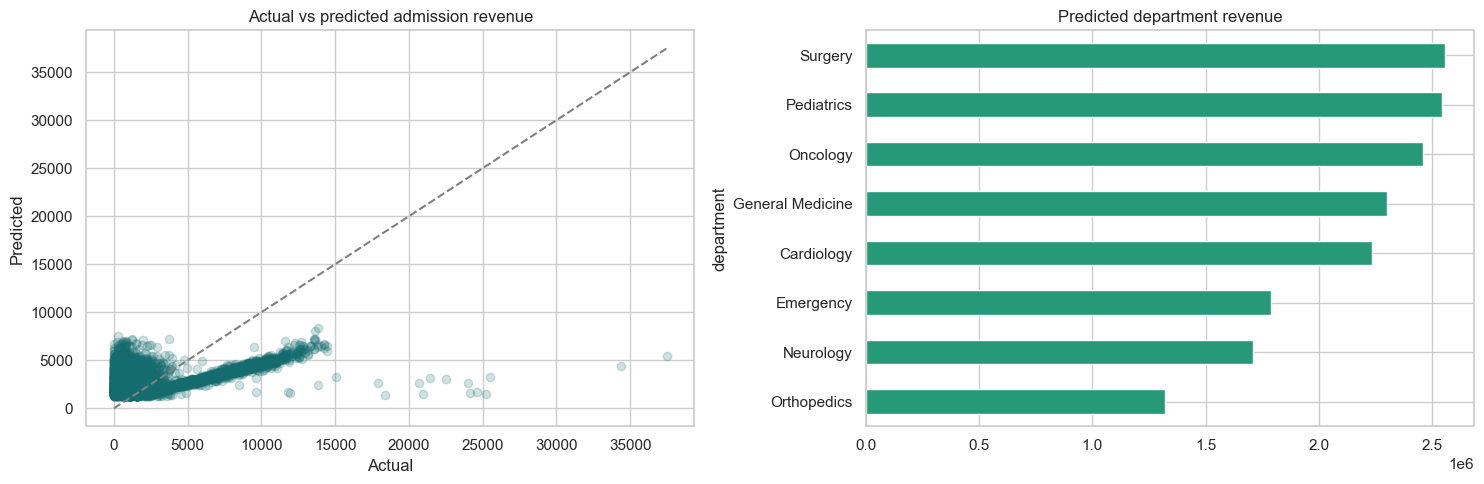

In [4]:
best_name = results.iloc[0]["model"]
best_model = fitted_models[best_name]
prediction = prediction_map[best_name]
evaluation = experiment.loc[X_test.index, ["department"]].copy()
evaluation["actual_revenue"] = y_test
evaluation["predicted_revenue"] = prediction

department_forecast = evaluation.groupby("department", as_index=False)[
    ["actual_revenue", "predicted_revenue"]
].sum()
display(department_forecast.sort_values("predicted_revenue", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(y_test, prediction, alpha=0.2, color="#146C6E")
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "--", color="gray")
axes[0].set_title("Actual vs predicted admission revenue")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
department_forecast.sort_values("predicted_revenue").plot.barh(
    x="department", y="predicted_revenue", ax=axes[1],
    legend=False, color="#269A78"
)
axes[1].set_title("Predicted department revenue")
plt.tight_layout()
plt.show()

## 4. Daily and monthly planning views

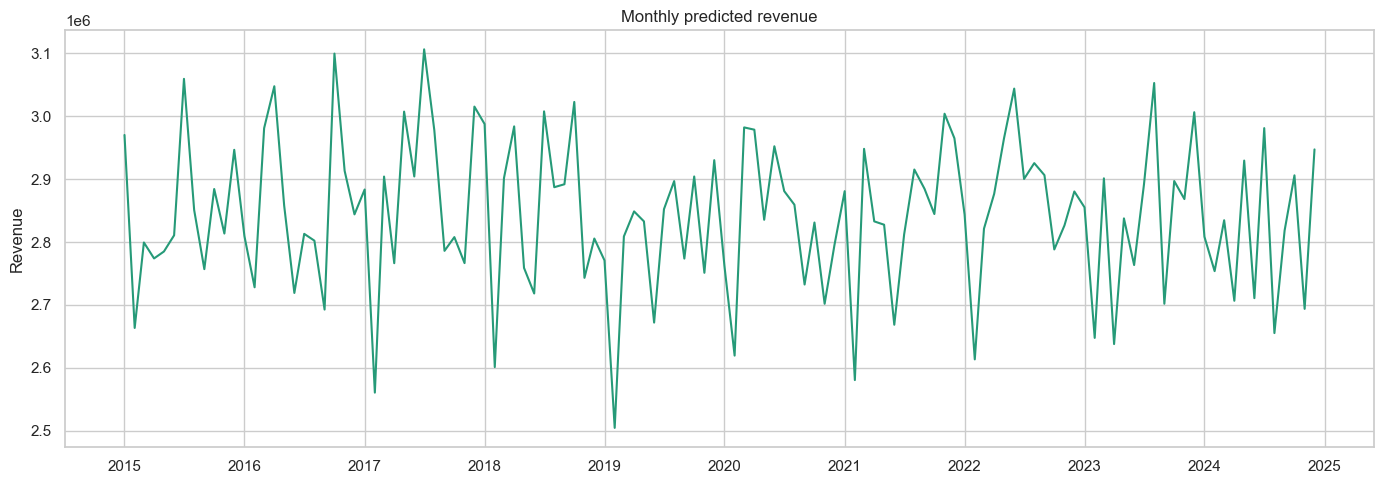

In [5]:
all_predictions = best_model.predict(data[REVENUE_FEATURES])
planning = data[["admit_date", "department"]].copy()
planning["predicted_revenue"] = np.maximum(all_predictions, 0)
daily_revenue = planning.groupby("admit_date", as_index=False)["predicted_revenue"].sum()
monthly_revenue = (
    daily_revenue.set_index("admit_date")
    .resample("MS")["predicted_revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue["admit_date"], monthly_revenue["predicted_revenue"], color="#269A78")
plt.title("Monthly predicted revenue")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## 5. Save model, forecasts, and conclusions

In [6]:
joblib.dump(best_model, EXPERIMENT_MODELS / "revenue_notebook.pkl")
results.to_csv(EXPERIMENT_REPORTS / "revenue_metrics.csv", index=False)
department_forecast.to_csv(EXPERIMENT_REPORTS / "department_revenue_forecast.csv", index=False)
daily_revenue.to_csv(EXPERIMENT_REPORTS / "daily_revenue_forecast.csv", index=False)
monthly_revenue.to_csv(EXPERIMENT_REPORTS / "monthly_revenue_forecast.csv", index=False)
print("Selected:", best_name)
print("Saved:", EXPERIMENT_MODELS / "revenue_notebook.pkl")

Selected: catboost
Saved: c:\Users\HP\Desktop\Hospital OP Inteligent sys\models\experiments\revenue_notebook.pkl


## Business conclusions

- Revenue predictions are most useful when aggregated into department and time views.
- Claim approval, billing category, LOS, and procedure intensity drive financial output.
- Zero paid revenue for denied claims requires guarded percentage metrics.
- Cost data is absent, so revenue must not be presented as profit.
- The surrogate admissions-claims link prevents real financial attribution until
  governed source keys are available.